# Phase 13 — Future Holdout Backtest

**เป้าหมาย:** ทดสอบโมเดลกับข้อมูลที่ **ไม่เคยถูกใช้เลย** ระหว่างพัฒนา (Phase 4–12) เพื่อตอบคำถามว่า
"ความแม่นยำที่วัดได้จาก CV จะยังอยู่ไหม เมื่อเจอข้อมูลอนาคตจริง"

Phase นี้มี 2 ส่วน ที่ตอบคำถามต่างกัน จึง **แยก protocol และไม่นำคะแนนมารวมกัน**:

| ส่วน | ข้อมูลทดสอบ | ขอบเขต | ตอบคำถาม |
|---|---|---|---|
| **A — Final holdout** | 10 origin weeks สุดท้าย (2024-10-21 → 2024-12-23) ที่กันไว้ตั้งแต่ Phase 5 | 30 SKU, ทุก channel/region | โมเดลที่เลือกจาก CV ยังแม่นเท่าเดิมไหมบนช่วงเวลาที่ไม่เคยเห็น |
| **B — January 2025** | batch รายสัปดาห์ 4 ไฟล์ `batch_MI-006_2025-01-*.parquet` | เฉพาะ MI-006 (9 series) | ถ้านำโมเดลไปใช้จริงกับข้อมูลใหม่ที่ส่งมาทีละสัปดาห์ จะเกิดอะไรขึ้น |

**กติกาที่ตั้งไว้ก่อนดูผล (pre-registered):**
- ไม่มีการปรับ hyperparameter, feature หรือเลือกโมเดลใหม่จากผล holdout — ใช้ค่า default ของ Phase 7 ทุกตัว
- **Global LightGBM เป็นโมเดลหลัก** (ตัดสินใจไว้แล้วใน Phase 7/12); XGBoost, CatBoost, Random Forest และ baseline 3 ตัวรายงานเป็นตัวเทียบ
- ทุกโมเดล fit **ครั้งเดียว** ต่อส่วน แล้วพยากรณ์ครั้งเดียว
- คะแนนหลักเป็น pooled WAPE (รวมทุกแถวแล้วคำนวณครั้งเดียว) พร้อม MAE/RMSE/SMAPE และ bias

โค้ดหลักอยู่ใน `src/models/holdout.py` — notebook นี้เป็นตัวรัน ตรวจสอบ และอธิบายผล

In [1]:
from pathlib import Path
import sys, json, warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), (
    'Could not locate repo root: expected an ancestor directory containing src/ '
    '(run from the repo root or any notebooks/ subfolder)'
)
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

from models.forecast import prepare_categoricals
from models.holdout import (
    MODELS, ML_MODELS, PRIMARY, KEYS, GROUP_KEYS, holdout_split, target_is_complete, fit_models,
    predict_models, baseline_predictions, build_ledger, score_ledger, cluster_bootstrap_wape_diff,
    load_january_batches, audit_data_contract, build_january_panel, replay_arrival_order, make_manifest,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

OUT = ROOT / 'reports/phase13'
FIG = ROOT / 'reports/figures'
OUT.mkdir(parents=True, exist_ok=True)

# Chart colors: reference categorical slots 1-3 (validated all-pairs) + neutral ink.
C_PRIMARY, C_MA, C_NAIVE = '#2a78d6', '#eb6834', '#1baf7a'
C_INK, C_MUTED, C_GRID = '#0b0b0b', '#8a8984', '#e4e3df'
plt.rcParams.update({'axes.edgecolor': C_MUTED, 'axes.labelcolor': C_INK, 'xtick.color': C_INK,
                     'ytick.color': C_INK, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.8})

daily = pd.read_csv(ROOT / 'data/interim/daily_validated.csv', parse_dates=['date'])
weekly = pd.read_csv(ROOT / 'data/processed/weekly_features.csv', parse_dates=['week'])
print('daily (Phase 3):', daily.shape, '| raw data ends', daily.date.max().date())
print('weekly features (Phase 4):', weekly.shape)

daily (Phase 3): (190757, 14) | raw data ends 2024-12-31
weekly features (Phase 4): (31027, 40)


## 1. ตรวจ label ของ holdout ก่อนใช้ — พบสัปดาห์สุดท้ายมีข้อมูลไม่ครบ

แต่ละแถวคือ "origin week" W ที่ใช้พยากรณ์ `target_next_week` = ยอดขายของสัปดาห์ W+1 (สัปดาห์ จันทร์–อาทิตย์
ตั้งชื่อตามวันจันทร์ ตามที่ตรวจไว้ใน Phase 3) ก่อนให้คะแนน ต้องยืนยันว่า **สัปดาห์ของ label มีข้อมูลรายวันครบ 7 วัน**

In [2]:
dfc = prepare_categoricals(weekly)
train_a, test_a, holdout_weeks = holdout_split(dfc)

labels = pd.DataFrame({'origin_week': holdout_weeks})
labels['label_week_start'] = labels.origin_week + pd.Timedelta(days=7)
labels['label_week_end'] = labels.label_week_start + pd.Timedelta(days=6)
labels['days_observed'] = [len(pd.date_range(s, min(e, daily.date.max()))) for s, e in
                           zip(labels.label_week_start, labels.label_week_end)]
labels['label_complete'] = target_is_complete(labels.origin_week, daily.date.max())
labels['sum_target_next_week'] = labels.origin_week.map(test_a.groupby('week').target_next_week.sum())
display(labels.assign(**{c: labels[c].dt.date for c in ['origin_week', 'label_week_start', 'label_week_end']}))
print('Training rows (all CV origins):', len(train_a), '| last training origin:', train_a.week.max().date())

,origin_week,label_week_start,label_week_end,days_observed,label_complete,sum_target_next_week
0,2024-10-21,2024-10-28,2024-11-03,7,True,26359.0
1,2024-10-28,2024-11-04,2024-11-10,7,True,25572.0
2,2024-11-04,2024-11-11,2024-11-17,7,True,25316.0
3,2024-11-11,2024-11-18,2024-11-24,7,True,26008.0
4,2024-11-18,2024-11-25,2024-12-01,7,True,26225.0
5,2024-11-25,2024-12-02,2024-12-08,7,True,26523.0
6,2024-12-02,2024-12-09,2024-12-15,7,True,24904.0
7,2024-12-09,2024-12-16,2024-12-22,7,True,26202.0
8,2024-12-16,2024-12-23,2024-12-29,7,True,25403.0
9,2024-12-23,2024-12-30,2025-01-05,2,False,7311.0


Training rows (all CV origins): 28336 | last training origin: 2024-10-14


**ผลลัพธ์:** origin สุดท้าย (2024-12-23) มี label เป็นยอดขายสัปดาห์ 2024-12-30 → 2025-01-05 แต่ข้อมูลดิบสิ้นสุดที่
2024-12-31 จึงมีข้อมูลเพียง **2 จาก 7 วัน** (ยอดรวม 7,311 เทียบกับ ~25,000–26,500 ของสัปดาห์อื่น) — นี่ไม่ใช่ยอดขายที่ลดลงจริง แต่เป็น
**label ที่ถูกตัด (truncated)** จากขอบเขตไฟล์ข้อมูล

ปัญหานี้ไม่เคยกระทบ Phase 6–12 เพราะ CV ไม่เคยแตะ 10 สัปดาห์นี้ แต่ถ้าให้คะแนนตรงๆ จะลงโทษทุกโมเดลอย่างไม่ยุติธรรม

**การตัดสินใจ (ก่อนดูคะแนน):** คะแนนหลักใช้ **9 origin weeks ที่ label ครบ** ส่วน origin 2024-12-23 รายงานแยกเป็น
sensitivity เพื่อให้เห็นขนาดผลกระทบ — และใน Part B label ของ MI-006 สัปดาห์นี้จะถูกเติมให้ครบด้วยข้อมูล batch มกราคม

## 2. Part A — Final holdout (30 SKU)

Fit ทุกโมเดลครั้งเดียวด้วย origin weeks ทั้งหมดของ CV (≤ 2024-10-14) แล้วพยากรณ์ 10 holdout weeks
ไม่มี leakage: แถว training สุดท้าย (origin 2024-10-14) มี label เป็นยอดขายสัปดาห์ 2024-10-21 ซึ่งเป็น *feature*
`units_sold` ของ holdout origin แรก ไม่ใช่ label ของ holdout แถวใด (convention เดียวกับทุก fold ใน CV)

Baseline (Naive / Seasonal Naive / Moving Average 4w) คำนวณจาก `units_sold` ของสัปดาห์ปัจจุบันและอดีตเท่านั้นเหมือน Phase 6

In [3]:
fitted_a = fit_models(train_a)
preds_a = predict_models(fitted_a, test_a)
test_a = test_a.assign(label_complete=target_is_complete(test_a.week, daily.date.max()))
ledger_a = build_ledger(test_a, preds_a, baseline_predictions(weekly), extra_cols=('label_complete', 'category'))
primary_a = ledger_a[ledger_a.label_complete]

cv = pd.read_csv(ROOT / 'reports/phase12/model_comparison.csv')
cv = cv[cv.comparison_group.eq('core_cv') & cv.coverage.eq(1)].set_index('model_id').WAPE
scores_a = score_ledger(primary_a)
scores_a['CV_WAPE_phase12'] = scores_a.model_id.map(cv)
scores_a['holdout_minus_CV'] = scores_a.WAPE - scores_a.CV_WAPE_phase12
display(scores_a.round(4))
print('Negative ML predictions:', {m: int((p < 0).sum()) for m, p in preds_a.items()})

,model_id,model,n_scored,coverage,MAE,RMSE,WAPE,SMAPE,bias,CV_WAPE_phase12,holdout_minus_CV
0,naive,Naive,2430,1.0,29.3144,37.2507,0.3064,0.3109,0.0046,0.3037,0.0026
1,seasonal_naive,Seasonal Naive,2430,1.0,30.9519,39.5204,0.3235,0.3195,0.0478,NaN,NaN
2,moving_avg_4,Moving Average (4w),2430,1.0,23.1820,29.6588,0.2423,0.2459,0.0106,0.2428,-0.0005
3,global_lgb,Global LightGBM,2430,1.0,21.4100,27.2482,0.2238,0.2283,0.0369,0.2235,0.0002
4,global_xgb,Global XGBoost,2430,1.0,21.4384,27.4500,0.2241,0.2285,0.0143,0.2240,0.0000
5,global_cb,Global CatBoost,2430,1.0,21.3473,27.2109,0.2231,0.2278,0.0355,NaN,NaN
6,global_rf,Global Random Forest,2430,1.0,21.6676,27.5590,0.2265,0.2310,0.0274,0.2241,0.0024


Negative ML predictions: {'global_lgb': 0, 'global_xgb': 0, 'global_cb': 0, 'global_rf': 0}


`CV_WAPE_phase12` = ค่าเฉลี่ย WAPE 7 folds จาก Phase 12 (เฉพาะโมเดลที่ coverage 100% ใน CV; Seasonal Naive มี
coverage 80% ใน CV จึงไม่เทียบ และ CatBoost ไม่ได้อยู่ใน Phase 12) — ใช้ดู **generalization gap** เท่านั้น
ไม่ใช่ตัวเลขชุดเดียวกัน (CV เป็นค่าเฉลี่ยราย fold, holdout เป็น pooled)

### 2.1 ความต่างของ WAPE เทียบโมเดลหลัก (cluster bootstrap)

holdout มีแค่ 9 สัปดาห์ จึงใช้ **bootstrap แบบสุ่มทั้ง series** (sku × channel × region, 270 series, 2,000 รอบ)
แทนการทดสอบราย fold — สุ่มทั้ง series เพื่อไม่นับสัปดาห์ติดกันของ series เดียวกันเป็นหลักฐานอิสระ
ค่าบวก = โมเดลเทียบคลาดเคลื่อน **มากกว่า** LightGBM; CI เป็น percentile 95%

In [4]:
boot_a = pd.DataFrame([cluster_bootstrap_wape_diff(primary_a, PRIMARY, m)
                       for m in ['global_xgb', 'global_cb', 'global_rf', 'moving_avg_4', 'naive', 'seasonal_naive']])
boot_a.insert(1, 'challenger', boot_a.model_b.map(MODELS))
boot_a['CI_excludes_0'] = (boot_a.ci_low > 0) | (boot_a.ci_high < 0)
display(boot_a.drop(columns=['model_a']).round(4))

,challenger,model_b,WAPE_a,WAPE_b,diff_b_minus_a,ci_low,ci_high,n_series,n_boot,CI_excludes_0
0,Global XGBoost,global_xgb,0.2238,0.2241,0.0003,-0.0017,0.0022,270,2000,False
1,Global CatBoost,global_cb,0.2238,0.2231,-0.0007,-0.0025,0.0011,270,2000,False
2,Global Random Forest,global_rf,0.2238,0.2265,0.0027,-0.0000,0.0052,270,2000,False
3,Moving Average (4w),moving_avg_4,0.2238,0.2423,0.0185,0.0147,0.0221,270,2000,True
4,Naive,naive,0.2238,0.3064,0.0826,0.0753,0.0903,270,2000,True
5,Seasonal Naive,seasonal_naive,0.2238,0.3235,0.0997,0.0899,0.1098,270,2000,True


### 2.2 ความสม่ำเสมอรายสัปดาห์และรายหมวดสินค้า

In [5]:
weekly_a = score_ledger(primary_a, by=('week',))
by_week = weekly_a.pivot(index='week', columns='model_id', values='WAPE')[list(MODELS)]
by_week.index = by_week.index.date
display(by_week.round(3))
print(f"LightGBM weekly WAPE range: {by_week[PRIMARY].min():.3f}–{by_week[PRIMARY].max():.3f}; "
      f"beats Moving Average (4w) in {(by_week[PRIMARY] < by_week.moving_avg_4).sum()}/{len(by_week)} weeks")

by_cat = score_ledger(primary_a, by=('category',)).pivot(index='category', columns='model_id', values='WAPE')[list(MODELS)]
display(by_cat.round(3))

model_id,naive,seasonal_naive,moving_avg_4,global_lgb,global_xgb,global_cb,global_rf
2024-10-21,0.300,0.342,0.230,0.208,0.208,0.208,0.211
2024-10-28,0.291,0.316,0.236,0.213,0.209,0.214,0.219
2024-11-04,0.296,0.341,0.241,0.231,0.229,0.228,0.234
2024-11-11,0.310,0.301,0.243,0.228,0.232,0.227,0.231
2024-11-18,0.311,0.328,0.248,0.225,0.223,0.221,0.225
2024-11-25,0.333,0.305,0.246,0.215,0.219,0.220,0.224
2024-12-02,0.298,0.323,0.240,0.237,0.239,0.234,0.235
2024-12-09,0.298,0.332,0.243,0.221,0.222,0.219,0.222
2024-12-16,0.321,0.324,0.253,0.238,0.238,0.237,0.238


LightGBM weekly WAPE range: 0.208–0.238; beats Moving Average (4w) in 9/9 weeks


model_id,naive,seasonal_naive,moving_avg_4,global_lgb,global_xgb,global_cb,global_rf
category,,,,,,,
Juice,0.284,0.277,0.226,0.223,0.213,0.232,0.225
Milk,0.311,0.343,0.243,0.226,0.225,0.223,0.225
ReadyMeal,0.293,0.298,0.242,0.218,0.225,0.220,0.223
SnackBar,0.293,0.348,0.230,0.213,0.208,0.210,0.221
Yogurt,0.321,0.316,0.250,0.232,0.233,0.232,0.233


### 2.3 Sensitivity: ถ้าให้คะแนน origin 2024-12-23 ที่ label ไม่ครบ

In [6]:
sens = pd.concat([
    score_ledger(ledger_a[~ledger_a.label_complete]).assign(scope='truncated origin only (2024-12-23)'),
    score_ledger(ledger_a).assign(scope='all 10 origins (naive scoring)'),
    score_ledger(primary_a).assign(scope='9 complete origins (primary)'),
])
display(sens.pivot(index='model', columns='scope', values='WAPE').loc[list(MODELS.values())].round(3))

scope,9 complete origins (primary),all 10 origins (naive scoring),truncated origin only (2024-12-23)
model,,,
Naive,0.306,0.370,2.378
Seasonal Naive,0.323,0.391,2.553
Moving Average (4w),0.242,0.308,2.398
Global LightGBM,0.224,0.299,2.690
Global XGBoost,0.224,0.296,2.587
Global CatBoost,0.223,0.297,2.644
Global Random Forest,0.226,0.298,2.568


### 2.4 กราฟสรุป Part A

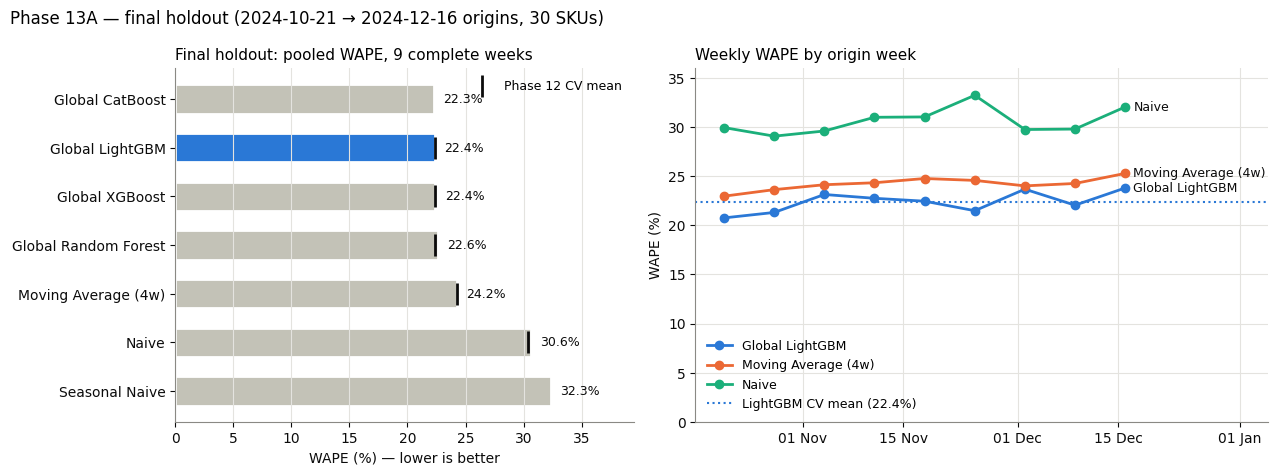

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [1, 1.25]})

order = scores_a.sort_values('WAPE').reset_index(drop=True)
ax = axes[0]
colors = [C_PRIMARY if m == PRIMARY else '#c3c2b7' for m in order.model_id]
ax.barh(order.model, order.WAPE * 100, color=colors, height=0.6, edgecolor='white', linewidth=2)
ax.scatter(order.CV_WAPE_phase12 * 100, order.model, marker='|', s=260, color=C_INK, linewidths=2,
           label='Phase 12 CV mean', zorder=3)
for y, (v, c) in enumerate(zip(order.WAPE, order.CV_WAPE_phase12)):
    ax.text(np.nanmax([v, c]) * 100 + 0.8, y, f'{v * 100:.1f}%', va='center', fontsize=9, color=C_INK)
ax.invert_yaxis()
ax.set_xlim(0, order.WAPE.max() * 100 * 1.22)
ax.set_xlabel('WAPE (%) — lower is better')
ax.set_title('Final holdout: pooled WAPE, 9 complete weeks', loc='left', fontsize=11)
ax.grid(axis='y', visible=False)
ax.legend(loc='upper right', frameon=False, fontsize=9)

ax = axes[1]
x = pd.to_datetime(by_week.index)
for model_id, color in [(PRIMARY, C_PRIMARY), ('moving_avg_4', C_MA), ('naive', C_NAIVE)]:
    ax.plot(x, by_week[model_id] * 100, marker='o', markersize=6, linewidth=2, color=color, label=MODELS[model_id])
    ax.annotate(MODELS[model_id], (x[-1], by_week[model_id].iloc[-1] * 100), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=9, color=C_INK)
ax.axhline(cv[PRIMARY] * 100, color=C_PRIMARY, linestyle=':', linewidth=1.5,
           label=f'LightGBM CV mean ({cv[PRIMARY] * 100:.1f}%)')
ax.set_ylim(0, 36)
ax.set_xlim(x[0] - pd.Timedelta(days=4), x[-1] + pd.Timedelta(days=20))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_ylabel('WAPE (%)')
ax.set_title('Weekly WAPE by origin week', loc='left', fontsize=11)
ax.legend(loc='lower left', frameon=False, fontsize=9)

fig.suptitle('Phase 13A — final holdout (2024-10-21 → 2024-12-16 origins, 30 SKUs)', x=0.01, ha='left')
fig.tight_layout()
fig.savefig(FIG / 'phase13_final_holdout.png', dpi=130)
plt.show()

### สรุป Part A

- **ไม่พบ generalization gap ที่มีนัยสำคัญเชิงปฏิบัติ:** Global LightGBM ได้ WAPE **0.2238** บน holdout เทียบกับ
  **0.2235** ใน CV ของ Phase 12 (ต่างกัน +0.0002) — Moving Average (4w) ก็ให้ผลเกือบเท่า CV เช่นกัน (0.2423 vs 0.2428)
  แปลว่าการออกแบบ walk-forward CV ใน Phase 5 ประเมินความแม่นยำได้ตรงกับของจริง
- **LightGBM ชนะ baseline ที่ดีที่สุดชัดเจน:** ต่ำกว่า Moving Average (4w) 1.85 percentage points (bootstrap 95% CI
  [1.47, 2.21]) และชนะทุกสัปดาห์ทั้ง 9 สัปดาห์
- **4 libraries ยังใกล้กันมาก** เหมือนใน Phase 7: CatBoost 0.2231, LightGBM 0.2238, XGBoost 0.2241, Random Forest 0.2265
  CI ของ CatBoost และ XGBoost ครอบ 0 — Random Forest แย่กว่าเล็กน้อย (+0.0027) โดย CI แตะ 0 พอดี
  ผลนี้ **ไม่ใช่เหตุผลให้เปลี่ยนโมเดลหลัก** (ข้อตกลงก่อนดูผล) และยังสอดคล้องกับ Phase 7 ว่าผลไม่ขึ้นกับ library
- **Bias:** LightGBM พยากรณ์สูงกว่ายอดจริงรวม ~3.7% (XGBoost ที่เทรนด้วย L1 loss มี bias ต่ำกว่า ~1.4%)
  — ควรติดตามใน production เพราะ over-forecast ต่อเนื่องหมายถึงสต็อกส่วนเกิน
- **Label ที่ถูกตัด** สำคัญมาก: ถ้ารวม origin 2024-12-23 แบบไม่ตรวจ WAPE ของ LightGBM จะกลายเป็น ~0.30 (สูงขึ้น ~34%)
  ทั้งที่โมเดลไม่ได้แย่ลง — ปัญหาเป็นของข้อมูล ไม่ใช่ของโมเดล

## 3. Part B — January 2025 batches (MI-006)

### 3.1 Data contract audit — ตรวจก่อนนำข้อมูลใหม่เข้าโมเดล

ข้อมูลใหม่ที่ส่งมาทีละสัปดาห์ต้อง "หน้าตาเหมือน" ข้อมูลที่โมเดลเรียนมา ไม่ใช่แค่ชื่อคอลัมน์ตรงกัน
ตารางด้านล่างเทียบ batch กับประวัติ MI-006 ช่วง 2022–2024 (ข้อมูลรายวัน, หลังผ่าน Phase 3)
`consistent` เป็นธงเชิงพรรณนาว่า property ที่ pipeline พึ่งพายังเหมือนเดิมไหม ไม่ใช่ hypothesis test

In [8]:
batches = load_january_batches(ROOT / 'data/raw')
print(batches.groupby('batch_file').agg(rows=('sku', 'size'), first_day=('date', 'min'), last_day=('date', 'max')))
audit = audit_data_contract(daily, batches, 'MI-006')
display(audit)
print(f"{(~audit.consistent).sum()} / {len(audit)} contract checks inconsistent")

                                 rows  first_day   last_day
batch_file                                                 
batch_MI-006_2025-01-06.parquet   135 2025-01-01 2025-01-05
batch_MI-006_2025-01-13.parquet   189 2025-01-06 2025-01-12
batch_MI-006_2025-01-20.parquet   189 2025-01-13 2025-01-19
batch_MI-006_2025-01-27.parquet   189 2025-01-20 2025-01-26


,check,history,batch,consistent,why_it_matters
0,columns and dtypes,14 columns,identical,True,Pipeline code must read the batch unchanged.
1,SKUs in batch,MI-006,MI-006,True,Cross-SKU features can't be recomputed from a ...
2,date range,2022-01-21 → 2024-12-31,2025-01-01 → 2025-01-26,True,Batches must continue the history without over...
3,duplicate series-day rows,0,468,False,Weekly units_sold is a SUM of daily rows; extr...
4,rows per series-day,1–1,3–3,False,Same as above.
5,share of calendar days with a row,0.85,1.00,False,Weekly sums depend on how many days are recorded.
6,units_sold per row: mean [min–max],16.13 [0–94],19.90 [10–29] (KS D=0.29),False,Per-row distribution the model learned from.
7,price_unit per row: mean [min–max],5.24 [1.5–9],5.50 [3.76–6.98] (KS D=0.38),False,Per-row distribution the model learned from.
8,stock_available per row: mean [min–max],158.05 [0–352],127.84 [50–199] (KS D=0.24),False,Per-row distribution the model learned from.
9,delivered_qty per row: mean [min–max],179.48 [2–330],89.76 [60–119] (KS D=0.93),False,Per-row distribution the model learned from.


11 / 14 contract checks inconsistent


**ผลลัพธ์:** schema ตรงกันทุกคอลัมน์ (มีต่างเพียงความละเอียดของ timestamp ใน parquet ซึ่ง loader แปลงให้แล้ว) แต่
**เนื้อข้อมูลไม่ได้มาจากกระบวนการเดียวกับประวัติ**:

- ประวัติมี **ไม่เกิน 1 แถวต่อ series ต่อวัน** (มีแถว ~85% ของวัน, `pack_type` สุ่มต่อแถว) แต่ batch มี **3 แถวทุกวัน**
  (ครบทุก `pack_type`) — weekly `units_sold` เป็นผลรวมรายวัน จึงพองขึ้นทันที
- `units_sold` ต่อแถวเป็นจำนวนเต็ม **10–29 เท่านั้น** (ประวัติ 0–94), `delivered_qty`, `stock_available`, `price_unit`
  อยู่ในช่วงแคบผิดธรรมชาติ, อัตราโปรโมชันเพิ่มจาก ~14% เป็น ~41%
- **ความสัมพันธ์ promo → ยอดขายหายไปทั้งหมด:** ประวัติ promo ขายได้ ~1.9× ต่อแถว แต่ใน batch 0.97× (ไม่ต่างกัน)

ลักษณะนี้บ่งชี้ว่า batch มกราคมสร้างจาก generator/รูปแบบการรายงานคนละแบบกับข้อมูลฝึก (data contract break)
ไม่ใช่การเปลี่ยนพฤติกรรมผู้บริโภค ในระบบจริงขั้นนี้ควร **หยุดและสอบถามเจ้าของข้อมูล** ก่อนใช้ — แต่ Phase 13
ยังรัน backtest ต่อตามแผน เพื่อวัดว่าโมเดลจะพังแค่ไหนถ้าไม่มีการตรวจนี้

### 3.2 แยกขนาดของการเลื่อนระดับ (level shift)

ยอดรายสัปดาห์ต่อ series = (จำนวนแถวต่อสัปดาห์) × (ยอดเฉลี่ยต่อแถว) จึงแยกได้ว่าระดับที่เพิ่มขึ้นมาจากส่วนไหน

In [9]:
def week_parts(d):
    g = d.set_index('date').groupby(GROUP_KEYS).resample('W-MON', label='left', closed='left').units_sold
    return pd.DataFrame({'rows': g.size(), 'units': g.sum()}).query('rows > 0')

full_weeks = batches[batches.date >= '2025-01-06']
ref = daily[daily.sku.eq('MI-006') & daily.date.between('2024-10-28', '2024-12-29')]  # last 9 full weeks of 2024
parts = pd.DataFrame({'Q4 2024 (9 full weeks)': week_parts(ref).mean(), 'Jan 2025 (3 full weeks)': week_parts(full_weeks).mean()}).T
parts['units_per_row'] = parts.units / parts.rows
ratio = parts.iloc[1] / parts.iloc[0]
display(parts.round(2))
print(f"rows per series-week ×{ratio.rows:.2f}  ×  units per row ×{ratio.units_per_row:.2f}  "
      f"=  weekly units per series ×{ratio.units:.2f}")

,rows,units,units_per_row
Q4 2024 (9 full weeks),5.8,76.15,13.12
Jan 2025 (3 full weeks),21.0,416.22,19.82


rows per series-week ×3.62  ×  units per row ×1.51  =  weekly units per series ×5.47


ระดับยอดรายสัปดาห์ต่อ series เพิ่มขึ้น **~5.5 เท่า** โดย **ส่วนใหญ่มาจากจำนวนแถวต่อสัปดาห์** (~3.6×) และส่วนที่เหลือจากยอดต่อแถว (~1.5×)

### 3.3 สร้าง feature ของสัปดาห์ใหม่ด้วยโค้ดเดิม + ตรวจ leakage

`build_january_panel()` ต่อ batch เข้ากับข้อมูลรายวันของ MI-006 แล้วสร้างตารางรายสัปดาห์ด้วยฟังก์ชันเดียวกับ Phase 4:

| Feature | วิธีได้ค่าในเดือนมกราคม |
|---|---|
| base (lag/rolling/target/calendar/lifecycle), `price_avg`, `promo_rate`, `stock_avg`, `deliveries`, `promo_recency`, `rolling_promo_rate`, `cross_channel_demand_share` | คำนวณใหม่จากข้อมูลของ MI-006 เอง (ไม่ต้องใช้ SKU อื่น) |
| `inflation_index`, `school_in_session`, `event_score`, `avg_temp` | generator เดิมของ Phase 4 บนช่วงสัปดาห์ที่ขยายถึงสิ้นปี 2025 (ช่วงคงที่ เพื่อให้ค่าไม่ขึ้นกับจำนวน batch ที่มาถึง) — ยังเป็น synthetic proxy เหมือนเดิม |
| `category_trend`, `price_index` | **ใช้ค่าล่าสุดที่รู้ (carry-forward)** ของสัปดาห์ 2024-12-23 เพราะต้องใช้ยอด/ราคาของ Milk SKU อื่นซึ่งไม่มีใน batch — ไม่ใช้ข้อมูลมกราคมของ MI-006 ปลอมเป็นค่าเฉลี่ยหมวด |

ตรวจ 2 อย่าง: (1) ประวัติที่สร้างใหม่ต้องตรงกับ `weekly_features.csv` ทุกค่า (2) **arrival-order replay** —
สร้างใหม่ทีละ batch ตามลำดับที่มาถึง แล้วยืนยันว่า feature ของทุก origin ที่ให้คะแนนได้ ณ เวลานั้นเหมือนกับตอนมีครบ 4 batch
(ถ้าไม่เหมือน แปลว่ามี feature ที่แอบใช้ข้อมูลอนาคต)

In [10]:
panel, history_check = build_january_panel(daily, batches, weekly)
print(f"History rebuild: {history_check.mismatches.sum()} mismatches across {len(history_check)} columns "
      f"× {history_check.rows_compared.iloc[0]} rows")
replay = replay_arrival_order(daily, batches, weekly, panel)
display(replay)
assert history_check.mismatches.sum() == 0 and replay.feature_mismatches.eq(0).all()

summary_cols = dict(series=('sku', 'size'), units_sold=('units_sold', 'sum'), target_next_week=('target_next_week', 'sum'),
                    deliveries=('deliveries', 'mean'), promo_rate=('promo_rate', 'mean'))
display(panel.groupby(['week', 'label_week']).agg(**summary_cols).round(2))
old = weekly[weekly.sku.eq('MI-006') & weekly.week.eq('2024-12-23')].target_next_week.sum()
print(f"Origin 2024-12-23 label: {old:.0f} in weekly_features.csv (2 days) → {panel[panel.week.eq('2024-12-23')].target_next_week.sum():.0f} "
      "with January batch 1 (full week)")

History rebuild: 0 mismatches across 30 columns × 1341 rows


,batches_available,last_file,data_through,scorable_origins,rows,feature_mismatches
0,1,batch_MI-006_2025-01-06.parquet,2025-01-05,2024-12-23,8,0
1,2,batch_MI-006_2025-01-13.parquet,2025-01-12,"2024-12-23, 2024-12-30",17,0
2,3,batch_MI-006_2025-01-20.parquet,2025-01-19,"2024-12-23, 2024-12-30, 2025-01-06",26,0
3,4,batch_MI-006_2025-01-27.parquet,2025-01-26,"2024-12-23, 2024-12-30, 2025-01-06, 2025-01-13",35,0


,,series,units_sold,target_next_week,deliveries,promo_rate
week,label_week,,,,,
2024-12-23,2024-12-30,8,664,2588.0,5.62,0.19
2024-12-30,2025-01-06,9,2902,3837.0,16.56,0.35
2025-01-06,2025-01-13,9,3837,3648.0,21.00,0.41
2025-01-13,2025-01-20,9,3648,3753.0,21.00,0.41


Origin 2024-12-23 label: 169 in weekly_features.csv (2 days) → 2588 with January batch 1 (full week)


**ผลลัพธ์:** ประวัติที่สร้างใหม่ตรงกับไฟล์เดิม 100% และ replay ไม่พบ feature ใดเปลี่ยนเมื่อ batch ถัดไปมาถึง —
ยืนยันว่า backtest ไม่มี leakage จากอนาคต ได้ origin ที่ให้คะแนนได้ 4 สัปดาห์ × 9 series (origin 2024-12-23 มี 8 series
เพราะ series Retail/PL-North ไม่มีแถวของสัปดาห์นั้นในตารางเดิม) = **35 forecasts**

ข้อสังเกต: `deliveries` (จำนวนแถวรายวันต่อสัปดาห์) กระโดดจาก ~6 เป็น 21 — feature ก็หลุดช่วงที่โมเดลเคยเห็นเช่นกัน

### 3.4 Backtest: refit บนทุกสัปดาห์ที่ label ครบของ 2022–2024 แล้วพยากรณ์มกราคม

จำลองการใช้งานจริง: หลังให้คะแนน Part A แล้ว โมเดลถูก refit ด้วยข้อมูลทั้งหมดที่ label ครบ (origin ≤ 2024-12-16, 30 SKU)
และ **ไม่ retrain ระหว่างเดือนมกราคม** — แต่ละสัปดาห์ใช้ feature ล่าสุดพยากรณ์สัปดาห์ถัดไป (one-step-ahead)

In [11]:
combined = prepare_categoricals(pd.concat([weekly.assign(_part='history'), panel[weekly.columns].assign(_part='january')],
                                          ignore_index=True))
train_b = combined[combined._part.eq('history') & target_is_complete(combined.week, daily.date.max())]
eval_b = combined[combined._part.eq('january')].assign(label_week=lambda d: d.week + pd.Timedelta(days=7))
assert train_b.week.max() < eval_b.week.min()
print('Training rows:', len(train_b), '| last training origin:', train_b.week.max().date())

fitted_b = fit_models(train_b)
preds_b = predict_models(fitted_b, eval_b)
mi006_series = pd.concat([weekly[weekly.sku.eq('MI-006') & weekly.week.lt('2024-12-23')], panel[weekly.columns]])
ledger_b = build_ledger(eval_b, preds_b, baseline_predictions(mi006_series), extra_cols=('label_week',))

scores_b = score_ledger(ledger_b)
mi006_a = score_ledger(primary_a[primary_a.sku.eq('MI-006')]).set_index('model_id')
scores_b['MI006_final_holdout_WAPE'] = scores_b.model_id.map(mi006_a.WAPE)
display(scores_b.round(3))

Training rows: 30766 | last training origin: 2024-12-16


,model_id,model,n_scored,coverage,MAE,RMSE,WAPE,SMAPE,bias,MI006_final_holdout_WAPE
0,naive,Naive,35,1.0,100.657,132.022,0.255,0.390,-0.201,0.298
1,seasonal_naive,Seasonal Naive,35,1.0,321.743,325.758,0.814,1.372,-0.814,0.330
2,moving_avg_4,Moving Average (4w),35,1.0,203.436,217.181,0.515,0.762,-0.515,0.225
3,global_lgb,Global LightGBM,35,1.0,288.358,290.606,0.730,1.151,-0.730,0.223
4,global_xgb,Global XGBoost,35,1.0,282.004,284.780,0.714,1.115,-0.714,0.223
5,global_cb,Global CatBoost,35,1.0,288.506,290.991,0.730,1.153,-0.730,0.219
6,global_rf,Global Random Forest,35,1.0,282.118,284.527,0.714,1.118,-0.714,0.216


In [12]:
by_label = score_ledger(ledger_b, by=('label_week',)).pivot(index='label_week', columns='model_id', values='WAPE')[list(MODELS)]
by_label.index = by_label.index.date
display(by_label.round(3))

totals = ledger_b.pivot_table(index='label_week', columns='model_id', values='prediction', aggfunc='sum')[list(MODELS)]
totals.insert(0, 'ACTUAL', ledger_b[ledger_b.model_id.eq(PRIMARY)].groupby('label_week').actual.sum())
totals.index = totals.index.date
display(totals.round(0))

hist_weeks = weekly[weekly.sku.eq('MI-006') & target_is_complete(weekly.week, daily.date.max())]
print(f"Largest weekly label of any MI-006 series in training: {hist_weeks.target_next_week.max():.0f} units; "
      f"smallest January label: {eval_b[eval_b.week.ge('2024-12-30')].target_next_week.min():.0f}; "
      f"largest LightGBM January forecast: {preds_b[PRIMARY].max():.0f}")

model_id,naive,seasonal_naive,moving_avg_4,global_lgb,global_xgb,global_cb,global_rf
2024-12-30,0.743,0.782,0.763,0.758,0.748,0.763,0.766
2025-01-06,0.244,0.822,0.676,0.744,0.769,0.763,0.759
2025-01-13,0.097,0.794,0.435,0.708,0.680,0.690,0.679
2025-01-20,0.083,0.848,0.257,0.718,0.666,0.714,0.667


model_id,ACTUAL,naive,seasonal_naive,moving_avg_4,global_lgb,global_xgb,global_cb,global_rf
2024-12-30,2588.0,664.0,563.0,614.0,625.0,651.0,614.0,605.0
2025-01-06,3837.0,2902.0,682.0,1243.0,984.0,885.0,910.0,924.0
2025-01-13,3648.0,3837.0,750.0,2061.0,1066.0,1168.0,1131.0,1172.0
2025-01-20,3753.0,3648.0,570.0,2788.0,1058.0,1252.0,1073.0,1251.0


Largest weekly label of any MI-006 series in training: 248 units; smallest January label: 374; largest LightGBM January forecast: 128


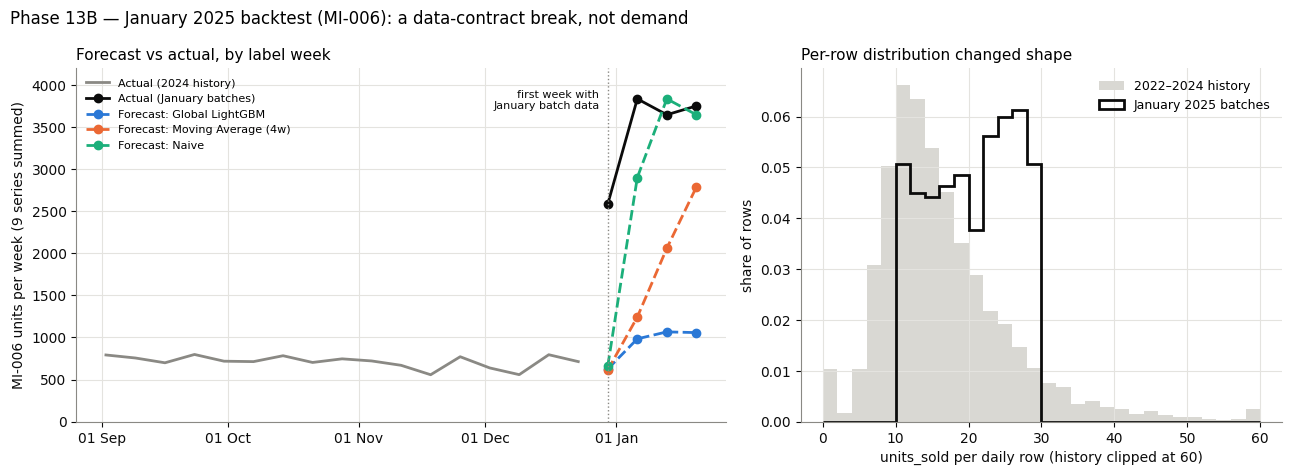

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [1.35, 1]})

ax = axes[0]
hist_total = weekly[weekly.sku.eq('MI-006') & weekly.week.between('2024-08-26', '2024-12-16')]
hist_total = hist_total.groupby(hist_total.week + pd.Timedelta(days=7)).target_next_week.sum()
actual = totals.ACTUAL.copy(); actual.index = pd.to_datetime(actual.index)
ax.plot(hist_total.index, hist_total, color=C_MUTED, linewidth=2, label='Actual (2024 history)')
ax.plot(actual.index, actual, color=C_INK, linewidth=2, marker='o', markersize=6, label='Actual (January batches)')
for model_id, color in [(PRIMARY, C_PRIMARY), ('moving_avg_4', C_MA), ('naive', C_NAIVE)]:
    s = totals[model_id]; s.index = pd.to_datetime(s.index)
    ax.plot(s.index, s, color=color, linewidth=2, marker='o', markersize=6, linestyle='--', label=f'Forecast: {MODELS[model_id]}')
ax.axvline(pd.Timestamp('2024-12-30'), color=C_MUTED, linewidth=1, linestyle=':')
ax.text(pd.Timestamp('2024-12-28'), 3950, 'first week with\nJanuary batch data', ha='right', va='top', fontsize=8, color=C_INK)
ax.set_ylim(0, 4200)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_ylabel('MI-006 units per week (9 series summed)')
ax.set_title('Forecast vs actual, by label week', loc='left', fontsize=11)
ax.legend(loc='upper left', frameon=False, fontsize=8)

ax = axes[1]
hist_rows = daily[daily.sku.eq('MI-006')].units_sold
bins = np.arange(0, 61, 2)
ax.hist(hist_rows.clip(upper=60), bins=bins, density=True, histtype='stepfilled', color='#d9d8d3', label='2022–2024 history')
ax.hist(batches.units_sold, bins=bins, density=True, histtype='step', color=C_INK, linewidth=2, label='January 2025 batches')
ax.set_xlabel('units_sold per daily row (history clipped at 60)')
ax.set_ylabel('share of rows')
ax.set_title('Per-row distribution changed shape', loc='left', fontsize=11)
ax.legend(frameon=False, fontsize=9)

fig.suptitle('Phase 13B — January 2025 backtest (MI-006): a data-contract break, not demand', x=0.01, ha='left')
fig.tight_layout()
fig.savefig(FIG / 'phase13_january_backtest.png', dpi=130)
plt.show()

### สรุป Part B

- **ทุกโมเดล ML พลาดหนักเท่ากัน:** WAPE ~0.71–0.73 และ bias ราว −72% (พยากรณ์ ~1,000 หน่วย/สัปดาห์ ขณะที่จริง ~3,700)
  เทียบกับ WAPE ~0.22 ของ MI-006 เองใน Part A — โมเดลไม่ได้ "แย่ลง" แต่ข้อมูลที่ให้คะแนนเปลี่ยนนิยามไป
- **Tree models extrapolate ไม่ได้:** label รายสัปดาห์สูงสุดของ series ใดๆ ของ MI-006 ในข้อมูลฝึกคือ 248 หน่วย
  แต่ label ที่ **ต่ำที่สุด** ของเดือนมกราคมคือ 374 — ต้นไม้พยากรณ์ได้ภายในช่วงค่าที่เคยเห็นเท่านั้น (forecast สูงสุดของ
  LightGBM ในเดือนมกราคมคือ 128) จึงตามระดับใหม่ไม่ทันไม่ว่าจะเป็น library ไหน
- **Naive ดูเหมือน "ชนะ" (WAPE 0.255) แต่ไม่ใช่หลักฐานว่าดีกว่า:** Naive แค่คัดลอกยอดสัปดาห์ล่าสุด ซึ่งมีระดับใหม่อยู่แล้ว
  (สัปดาห์แรกยังพลาด 0.74 เท่ากับทุกโมเดล) Moving Average ไล่ตามทีละน้อยตามหน้าต่าง 4 สัปดาห์ ใน Part A ที่ข้อมูลปกติ
  Naive แย่ที่สุดอันดับสอง (0.306)
- **ข้อสรุปเชิงธุรกิจ:** คะแนน Part B วัด **ความเสียหายของ data contract break** ไม่ใช่ความแม่นยำของโมเดลต่อ demand จริง
  สิ่งที่ Phase นี้พิสูจน์ได้คือ (1) ต้องมี contract audit แบบ 3.1 เป็นด่านก่อนนำ batch ใหม่เข้าระบบ และ
  (2) **ห้าม retrain ด้วย batch เหล่านี้** จนกว่าจะยืนยันกับเจ้าของข้อมูลว่า 3 แถว/วัน และช่วงค่า 10–29 เป็นรูปแบบการรายงานใหม่
  หรือข้อผิดพลาด — ถ้าเป็นรูปแบบใหม่จริง ต้องปรับ roll-up (เช่น นิยาม grain ต่อ pack_type) แล้ว rebuild ทั้งตาราง
- ข้อจำกัด: 35 forecasts จาก SKU เดียว ไม่พอสำหรับเทียบโมเดลเชิงสถิติ จึงรายงานเชิงพรรณนาเท่านั้น

## 4. บันทึกผลลัพธ์และ manifest

In [14]:
fmt = dict(index=False, date_format='%Y-%m-%d')
scores_a.assign(scope='final_holdout_9_complete_weeks').to_csv(OUT / 'final_holdout_scores.csv', **fmt)
weekly_a.to_csv(OUT / 'final_holdout_weekly_scores.csv', **fmt)
boot_a.to_csv(OUT / 'final_holdout_bootstrap.csv', **fmt)
sens.to_csv(OUT / 'final_holdout_truncated_label_sensitivity.csv', **fmt)
ledger_a.to_csv(OUT / 'final_holdout_predictions.csv', **fmt)
audit.to_csv(OUT / 'january_contract_audit.csv', **fmt)
replay.to_csv(OUT / 'january_arrival_replay.csv', **fmt)
scores_b.to_csv(OUT / 'january_scores.csv', **fmt)
ledger_b.to_csv(OUT / 'january_predictions.csv', **fmt)

manifest = make_manifest(
    ROOT,
    holdout_origin_weeks=[str(w.date()) for w in holdout_weeks],
    scored_holdout_origin_weeks=[str(w.date()) for w in labels.origin_week[labels.label_complete]],
    excluded_truncated_origin_weeks=[str(w.date()) for w in labels.origin_week[~labels.label_complete]],
    raw_data_last_date=str(daily.date.max().date()),
    part_a_training=dict(rows=len(train_a), last_origin=str(train_a.week.max().date()), fits_per_model=1),
    part_b_training=dict(rows=len(train_b), last_origin=str(train_b.week.max().date()), fits_per_model=1,
                         retrained_during_january=False),
    january_batches=sorted(batches.batch_file.unique()),
    january_scored_origins=[str(w.date()) for w in sorted(eval_b.week.unique())],
    january_forecasts=int(len(eval_b)),
    january_carried_forward_features=['category_trend', 'price_index'],
    january_contract_inconsistent_checks=audit.loc[~audit.consistent, 'check'].tolist(),
    history_rebuild_mismatches=int(history_check.mismatches.sum()),
    arrival_replay_feature_mismatches=int(replay.feature_mismatches.sum()),
    bootstrap=dict(unit='sku x channel x region series', n_boot=2000, seed=42, interval='percentile 95%'),
    hyperparameters_tuned_on_holdout=False,
)
(OUT / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False, default=str) + '\n', encoding='utf-8')
print('Saved:', ', '.join(sorted(p.name for p in OUT.iterdir())))

Saved: final_holdout_bootstrap.csv, final_holdout_predictions.csv, final_holdout_scores.csv, final_holdout_truncated_label_sensitivity.csv, final_holdout_weekly_scores.csv, january_arrival_replay.csv, january_contract_audit.csv, january_predictions.csv, january_scores.csv, run_manifest.json


ตรวจย้อนกลับว่าไฟล์ที่บันทึกคำนวณคะแนนกลับได้ตรงกัน และไม่มีแถว training ใดอยู่ในช่วงทดสอบ

In [15]:
saved_a = pd.read_csv(OUT / 'final_holdout_predictions.csv', parse_dates=['week'])
saved_b = pd.read_csv(OUT / 'january_predictions.csv', parse_dates=['week', 'label_week'])
pd.testing.assert_frame_equal(score_ledger(saved_a[saved_a.label_complete]).reset_index(drop=True),
                              score_ledger(primary_a).reset_index(drop=True), check_dtype=False, rtol=1e-9)
pd.testing.assert_frame_equal(score_ledger(saved_b).reset_index(drop=True), scores_b.drop(columns='MI006_final_holdout_WAPE'),
                              check_dtype=False, rtol=1e-9)
assert not train_a.week.isin(holdout_weeks).any()
assert train_b.week.max() < saved_b.week.min()
assert saved_a.groupby('model_id').size().nunique() == 1 and saved_b.groupby('model_id').size().eq(35).all()
print('PASS: saved predictions reproduce every score; no training origin overlaps any scored origin.')

PASS: saved predictions reproduce every score; no training origin overlaps any scored origin.


## 5. สรุป Phase 13

| หัวข้อ | ผลลัพธ์ |
|---|---|
| Label quality | origin 2024-12-23 มี label เพียง 2/7 วัน (ข้อมูลดิบจบ 2024-12-31) — แยกออกจากคะแนนหลัก, ถ้ารวมจะทำให้ WAPE สูงเกินจริง ~34% |
| Part A — final holdout (30 SKU, 2,430 forecasts) | Global LightGBM WAPE **0.2238** vs CV 0.2235 → ไม่มี generalization gap; ชนะ Moving Average (4w) 1.85 pp [1.47, 2.21] ทุกสัปดาห์ |
| Library robustness | CatBoost 0.2231 / LightGBM 0.2238 / XGBoost 0.2241 / RF 0.2265 — ใกล้กันเหมือน Phase 7, คงโมเดลหลักเดิม |
| Part B — January 2025 (MI-006, 35 forecasts) | Data contract audit พบ batch ต่างจากประวัติ 11/14 ข้อ (3 แถว/วัน, units 10–29, promo effect หาย) → ระดับยอดรายสัปดาห์ต่อ series ~5.5× |
| Part B scores | ML ทุกตัว WAPE ~0.71–0.73, bias ~−72%; Naive 0.255 จากการคัดลอกระดับใหม่ — วัดผลของ contract break ไม่ใช่ความแม่นยำต่อ demand |
| Leakage checks | ประวัติที่ rebuild ตรงไฟล์เดิม 100%; arrival-order replay ไม่พบ feature ใดขึ้นกับ batch ในอนาคต |
| Outputs | `reports/phase13/*` (scores, predictions, audit, replay, manifest), `reports/figures/phase13_*.png`, `src/models/holdout.py`, `tests/test_holdout.py` |

